In [1]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Code for Metric Score Calculations

In [2]:
def silhouette_score_modified(X, labels):

    X = np.asarray(X)
    labels = np.asarray(labels)

    n = len(X)
    unique_labels = np.unique(labels)

    # pairwise distance matrix
    D = cdist(X, X)

    # centroids
    centroids = {
        l: X[labels == l].mean(axis=0)
        for l in unique_labels
    }

    # distance to centroid
    dist_to_centroid = np.zeros(n)
    for i in range(n):
        d = np.linalg.norm(X[i] - centroids[labels[i]])
        dist_to_centroid[i] = d + 1e-8   # avoid zero

    silhouette_scores = np.zeros(n)

    for i in range(n):

        # a(i) 
        same_cluster = (labels == labels[i])
        same_cluster[i] = False  # exclude self

        if not np.any(same_cluster):
            silhouette_scores[i] = 0
            continue

        intra_dist = D[i, same_cluster]
        intra_weights = 1.0 / dist_to_centroid[same_cluster]

        a = np.sum(intra_dist * intra_weights) / np.sum(intra_weights)

        # b(i)
        b = np.inf

        for l in unique_labels:
            if l == labels[i]:
                continue

            mask = (labels == l)
            inter_dist = D[i, mask]
            inter_weights = 1.0 / dist_to_centroid[mask]

            b_l = np.sum(inter_dist * inter_weights) / np.sum(inter_weights)
            b = min(b, b_l)

        # silhouette score for i
        silhouette_scores[i] = (b - a) / max(a, b)

    return silhouette_scores.mean()

In [3]:
def silhouette_score_a_modified(X, labels):

    X = np.asarray(X)
    labels = np.asarray(labels)

    n = len(X)
    unique_labels = np.unique(labels)

    # pairwise distance matrix
    D = cdist(X, X)

    # centroids
    centroids = {
        l: X[labels == l].mean(axis=0)
        for l in unique_labels
    }

    # distance to centroid
    dist_to_centroid = np.zeros(n)
    for i in range(n):
        d = np.linalg.norm(X[i] - centroids[labels[i]])
        dist_to_centroid[i] = d + 1e-8   # avoid zero

    silhouette_scores = np.zeros(n)

    for i in range(n):

        # a(i) 
        same_cluster = (labels == labels[i])
        same_cluster[i] = False  # exclude self

        if not np.any(same_cluster):
            silhouette_scores[i] = 0
            continue

        intra_dist = D[i, same_cluster]
        intra_weights = 1.0 / dist_to_centroid[same_cluster]

        a = np.sum(intra_dist * intra_weights) / np.sum(intra_weights)

        # b(i)
        b = np.inf

        for l in unique_labels:
            if l == labels[i]:
                continue

            mask = (labels == l)
            inter_dist = D[i, mask]
            #inter_weights = 1.0 / dist_to_centroid[mask]

            b_l = np.sum(inter_dist) / len(inter_dist)
            b = min(b, b_l)

        # silhouette score for i
        silhouette_scores[i] = (b - a) / max(a, b)

    return silhouette_scores.mean()

In [4]:
def silhouette_score_b_modified(X, labels):

    X = np.asarray(X)
    labels = np.asarray(labels)

    n = len(X)
    unique_labels = np.unique(labels)

    # pairwise distance matrix
    D = cdist(X, X)

    # centroids
    centroids = {
        l: X[labels == l].mean(axis=0)
        for l in unique_labels
    }

    # distance to centroid
    dist_to_centroid = np.zeros(n)
    for i in range(n):
        d = np.linalg.norm(X[i] - centroids[labels[i]])
        dist_to_centroid[i] = d + 1e-8   # avoid zero

    silhouette_scores = np.zeros(n)

    for i in range(n):

        # a(i) 
        same_cluster = (labels == labels[i])
        same_cluster[i] = False  # exclude self

        if not np.any(same_cluster):
            silhouette_scores[i] = 0
            continue

        intra_dist = D[i, same_cluster]
        #intra_weights = 1.0 / dist_to_centroid[same_cluster]

        a = np.mean(intra_dist)

        # b(i)
        b = np.inf

        for l in unique_labels:
            if l == labels[i]:
                continue

            mask = (labels == l)
            inter_dist = D[i, mask]
            inter_weights = 1.0 / dist_to_centroid[mask]

            b_l = np.sum(inter_dist * inter_weights) / np.sum(inter_weights)
            b = min(b, b_l)

        # silhouette score for i
        silhouette_scores[i] = (b - a) / max(a, b)

    return silhouette_scores.mean()

# Experiment

In [5]:
rng = np.random.default_rng(51)

centroids = np.array([
    [5.0, 3.0],
    [7.0, 7.0],
    [3.0, 7.0]
])

n_samples_per_cluster = 67
std_values = [0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.5, 2.0]

runs = 10 

In [6]:
results = []

for std in std_values:
    for run in range(runs):
        
        X = np.vstack([
            rng.normal(loc=center, scale=std,
                             size=(n_samples_per_cluster, 2))
            for center in centroids
        ])

        labels = np.repeat([0, 1, 2], n_samples_per_cluster)

        s_std = silhouette_score(X, labels)
        s_mod = silhouette_score_modified(X, labels)
        s_a_mod = silhouette_score_a_modified(X, labels)
        s_b_mod = silhouette_score_b_modified(X, labels)

        results.append([std, run, s_std, s_mod,s_a_mod,s_b_mod])

In [7]:
df_results = pd.DataFrame(results, columns=["std", "run", "silhouette_standard", "silhouette_modified","only a(i) modified","only b(i) modified"])   
display(df_results)

,std,run,silhouette_standard,silhouette_modified,only a(i) modified,only b(i) modified
0,0.2,0,0.909272,0.922849,0.922823,0.909302
1,0.2,1,0.912503,0.925716,0.925783,0.912423
2,0.2,2,0.915860,0.927456,0.927632,0.915654
3,0.2,3,0.916480,0.929997,0.930175,0.916264
4,0.2,4,0.911308,0.922689,0.922751,0.911237
...,...,...,...,...,...,...
75,2.0,5,0.209656,0.255037,0.319305,0.141401
76,2.0,6,0.218918,0.265382,0.316597,0.166079
77,2.0,7,0.151987,0.192545,0.265388,0.077081
78,2.0,8,0.178268,0.218551,0.285505,0.107529


In [8]:
df_mean = df_results.groupby('std').mean().reset_index()
df_mean = df_mean.drop(['run'], axis=1)
display(df_mean)

,std,silhouette_standard,silhouette_modified,only a(i) modified,only b(i) modified
0,0.2,0.914778,0.926768,0.926827,0.914709
1,0.4,0.826595,0.850004,0.850292,0.826269
2,0.6,0.727720,0.762040,0.763542,0.726011
3,0.8,0.639800,0.682531,0.686391,0.635445
4,1.0,0.547511,0.597073,0.605857,0.537728
5,1.2,0.461738,0.517020,0.532256,0.445012
6,1.5,0.342152,0.397400,0.427302,0.310091
7,2.0,0.191910,0.234056,0.295915,0.127236


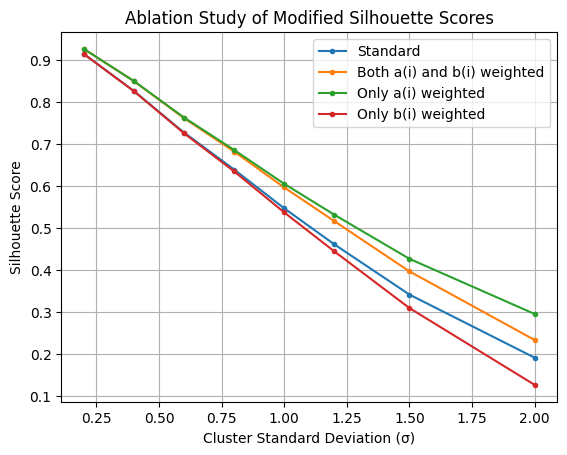

In [9]:
plt.figure()

plt.plot(df_mean["std"], df_mean["silhouette_standard"], marker='.', label="Standard")
plt.plot(df_mean["std"], df_mean["silhouette_modified"], marker='.', label="Both a(i) and b(i) weighted")
plt.plot(df_mean["std"], df_mean["only a(i) modified"], marker='.', label="Only a(i) weighted")
plt.plot(df_mean["std"], df_mean["only b(i) modified"], marker='.', label="Only b(i) weighted")

plt.xlabel("Cluster Standard Deviation (σ)")
plt.ylabel("Silhouette Score")
plt.title("Ablation Study of Modified Silhouette Scores")

plt.legend()
plt.grid()

plt.show()